<a href="https://colab.research.google.com/github/ealmeida04/logica-programacao/blob/main/Projeto_ebac_DASH.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Projeto E-commerce: Análise Estatística e Visualização de Dados
**Autor:** [EDUARDO DIAS]  
**Objetivo:** Analisar o comportamento de vendas, precificação e satisfação do cliente para extrair insights estratégicos.

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import plotly.express as px

# Lendo o arquivo (Certifique-se de fazer o upload do 'ecommerce_estatistica.csv' no ícone de pasta à esquerda)
try:
    df = pd.read_csv('ecommerce_estatistica.csv')
    print("Arquivo carregado com sucesso!")
    display(df.head())
except:
    print("Erro: Verifique se o arquivo 'ecommerce_estatistica.csv' foi enviado para o Colab.")

# Configurações de estilo
sns.set_theme(style="whitegrid")

Arquivo carregado com sucesso!


,Unnamed: 0,Título,Nota,N_Avaliações,Desconto,Marca,Material,Gênero,Temporada,Review1,...,Nota_MinMax,N_Avaliações_MinMax,Desconto_MinMax,Preço_MinMax,Marca_Cod,Material_Cod,Temporada_Cod,Qtd_Vendidos_Cod,Marca_Freq,Material_Freq
0,1,Kit 10 Cuecas Boxer Lupo Cueca Box Algodão Mas...,4.5,3034.0,18.0,lupo,algodão,Masculino,outono/inverno,As cuecas são boas; porém você percebe na cost...,...,0.814815,0.334178,0.213115,0.378585,463,25,3,10000.0,0.042292,0.176444
1,2,Kit Com 10 Cuecas Boxer Algodão Sem Costura Zo...,4.7,5682.0,20.0,zorba,algodão,Masculino,não definido,O tecido é bom e são confortáveis. Só que a nu...,...,0.888889,0.625937,0.245902,0.322329,838,25,1,50000.0,0.009095,0.176444
2,3,Kit 10 Cuecas Boxer Mash Algodão Cotton Box Or...,4.6,1700.0,22.0,mash,algodão,Masculino,primavera/verão,"As cuecas são boas, porém meu marido usa g e p...",...,0.851852,0.187197,0.278689,0.372617,494,25,7,10000.0,0.010914,0.176444
3,4,Kit 3 Short Jeans Feminino Cintura Alta Barato...,4.4,507.0,9.0,menina linda,jean,Feminino,primavera/verão,Estou encantada com essas peças!.\nOs shorts s...,...,0.777778,0.055751,0.065574,0.201767,509,74,7,1000.0,0.010005,0.025466
4,5,Blusa + Calça Térmica Treino Futebol Criança I...,4.7,58.0,5.0,roupa zero grau,termico unissex,Sem gênero infantil,outono/inverno,"Produto ótimo , mesmo após várias lavagens não...",...,0.888889,0.006280,0.000000,0.114508,669,166,3,100.0,0.002274,0.000910


/tmp/ipython-input-1715024406.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='Gênero', y='Nota', ax=axes[1, 1], palette='viridis')


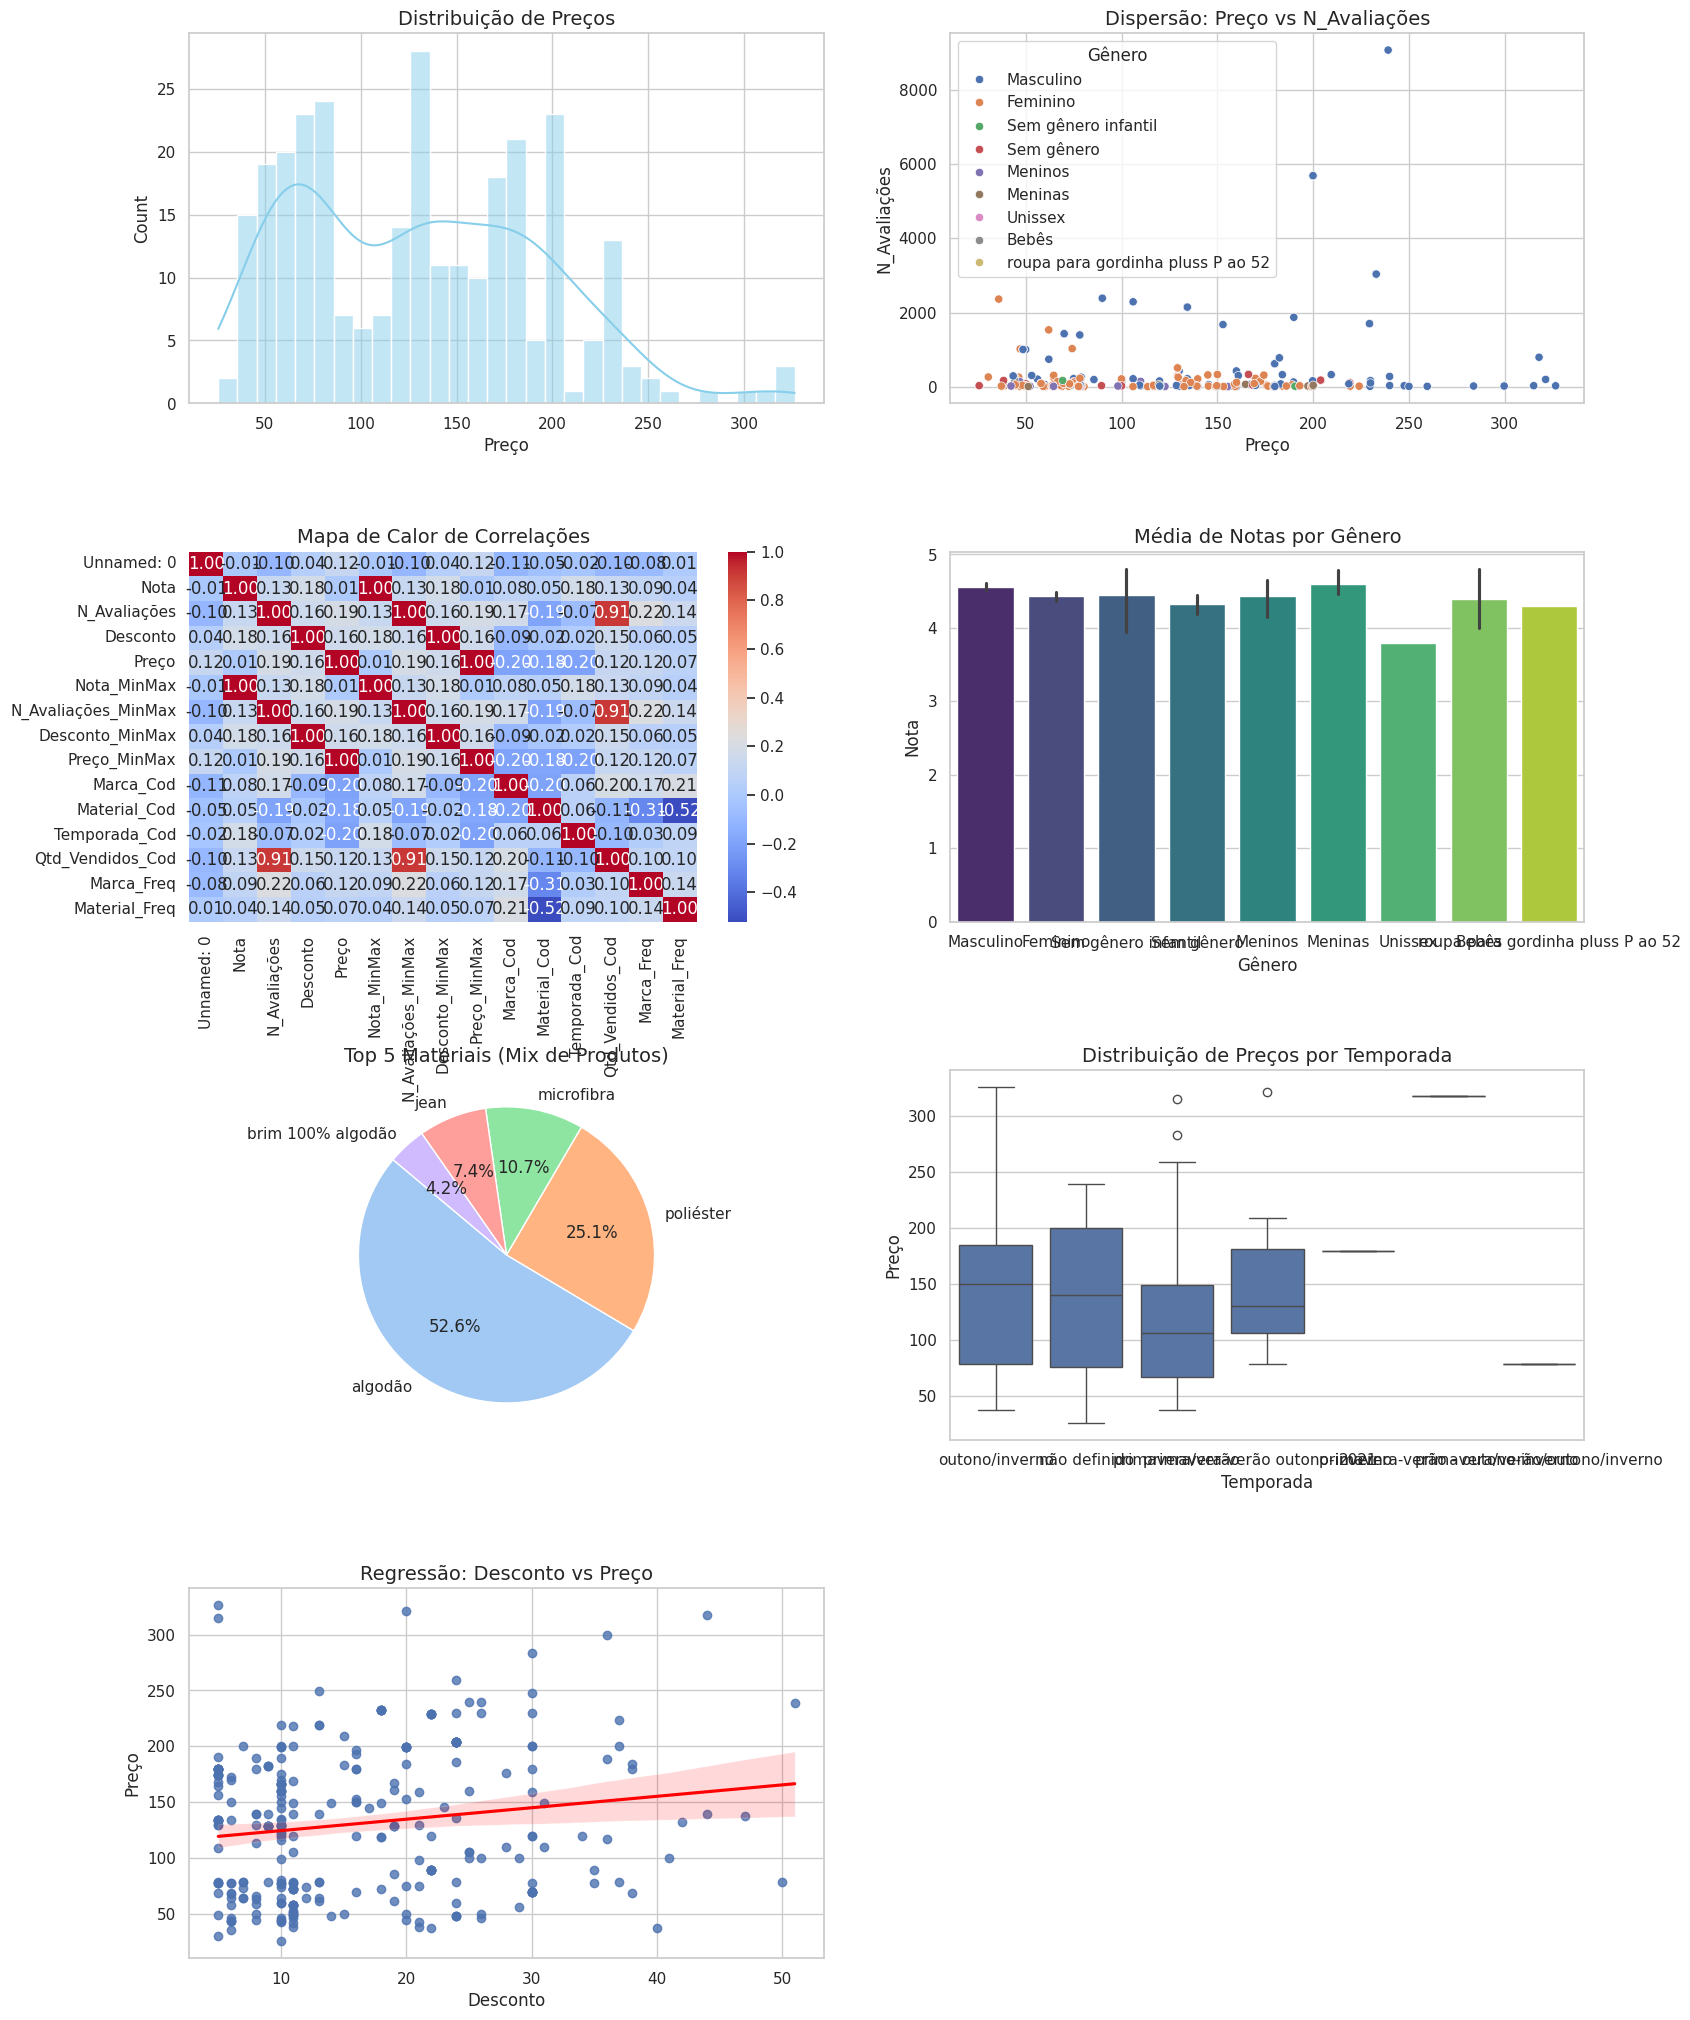

In [3]:
# Criando uma figura com vários subplots para organizar a entrega
fig, axes = plt.subplots(4, 2, figsize=(18, 25))
plt.subplots_adjust(hspace=0.4)

# 1. Histograma (Preços)
sns.histplot(df['Preço'], bins=30, kde=True, ax=axes[0, 0], color='skyblue')
axes[0, 0].set_title('Distribuição de Preços', fontsize=14)

# 2. Dispersão (Preço vs Avaliações)
sns.scatterplot(data=df, x='Preço', y='N_Avaliações', hue='Gênero', ax=axes[0, 1])
axes[0, 1].set_title('Dispersão: Preço vs N_Avaliações', fontsize=14)

# 3. Mapa de Calor (Correlação)
corr = df.select_dtypes(include=[np.number]).corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f", ax=axes[1, 0])
axes[1, 0].set_title('Mapa de Calor de Correlações', fontsize=14)

# 4. Gráfico de Barra (Nota por Gênero)
sns.barplot(data=df, x='Gênero', y='Nota', ax=axes[1, 1], palette='viridis')
axes[1, 1].set_title('Média de Notas por Gênero', fontsize=14)

# 5. Gráfico de Pizza (Materiais - Top 5)
top_mat = df['Material'].value_counts().head(5)
axes[2, 0].pie(top_mat, labels=top_mat.index, autopct='%1.1f%%', startangle=140, colors=sns.color_palette('pastel'))
axes[2, 0].set_title('Top 5 Materiais (Mix de Produtos)', fontsize=14)

# 6. Gráfico de U / Boxplot (Preço por Temporada)
sns.boxplot(data=df, x='Temporada', y='Preço', ax=axes[2, 1])
axes[2, 1].set_title('Distribuição de Preços por Temporada', fontsize=14)

# 7. Gráfico de Regressão (Desconto vs Preço)
sns.regplot(data=df, x='Desconto', y='Preço', ax=axes[3, 0], line_kws={'color':'red'})
axes[3, 0].set_title('Regressão: Desconto vs Preço', fontsize=14)

# Remover o último eixo vazio
fig.delaxes(axes[3, 1])

plt.show()

In [ ]:
!pip install dash

from dash import Dash, dcc, html
import threading

# Criando os gráficos interativos com Plotly
fig1 = px.histogram(df, x="Preço", title="Distribuição Interativa de Preços")
fig2 = px.scatter(df, x="Desconto", y="Qtd_Vendidos", color="Gênero", trendline="ols", title="Relação Desconto vs Vendas")

app = Dash(__name__)

app.layout = html.Div([
    html.H1("Dashboard E-commerce Interativo"),
    dcc.Graph(figure=fig1),
    dcc.Graph(figure=fig2)
])

# Rodar o servidor em uma porta específica para o Colab
if __name__ == '__main__':
    app.run_server(mode='inline', port=8050)

## Conclusões
1. **Preços:** A maior parte do catálogo está concentrada em faixas de preço menores, indicando uma estratégia de volume.
2. **Sazonalidade:** Certas temporadas apresentam maior variação de preços (outliers), o que pode indicar lançamentos de coleções premium.
3. **Engajamento:** Não há uma correlação linear forte entre desconto e nota, sugerindo que a qualidade do material pesa mais que o preço baixo na satisfação.